Dataset size: (380, 17)
Columns: ['appointment_id', 'patient_age', 'age_group', 'gender', 'region', 'insurance_type', 'appointment_type', 'booking_channel', 'days_before_appointment_booked', 'previous_no_shows', 'previous_appointments', 'appointment_hour', 'reminder_sent', 'travel_distance_km', 'clinic_wait_time_minutes', 'patient_satisfaction_score', 'no_show']
Data types:
 appointment_id                     object
patient_age                         int64
age_group                          object
gender                             object
region                             object
insurance_type                     object
appointment_type                   object
booking_channel                    object
days_before_appointment_booked      int64
previous_no_shows                   int64
previous_appointments               int64
appointment_hour                    int64
reminder_sent                      object
travel_distance_km                float64
clinic_wait_time_minutes          

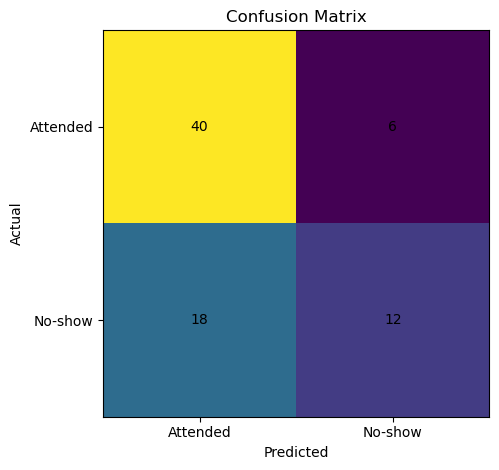

Error_Type
True Negative     40
False Negative    18
True Positive     12
False Positive     6
Name: count, dtype: int64
Wrong predictions:
    Actual  Predicted  Correct      Error_Type
2        1          0    False  False Negative
13       0          1    False  False Positive
16       1          0    False  False Negative
22       1          0    False  False Negative
24       0          1    False  False Positive
29       0          1    False  False Positive
32       1          0    False  False Negative
35       1          0    False  False Negative
37       1          0    False  False Negative
40       1          0    False  False Negative


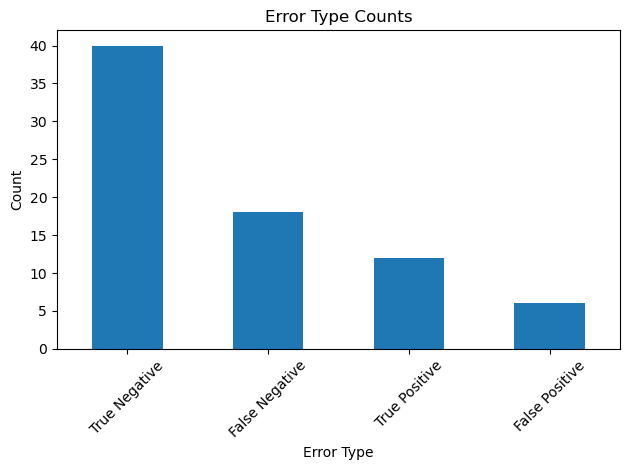

Cross-validation scores: [0.65789474 0.67105263 0.59210526 0.68421053 0.65789474]
Mean CV accuracy: 0.6526315789473685
CV standard deviation: 0.031797489404196265


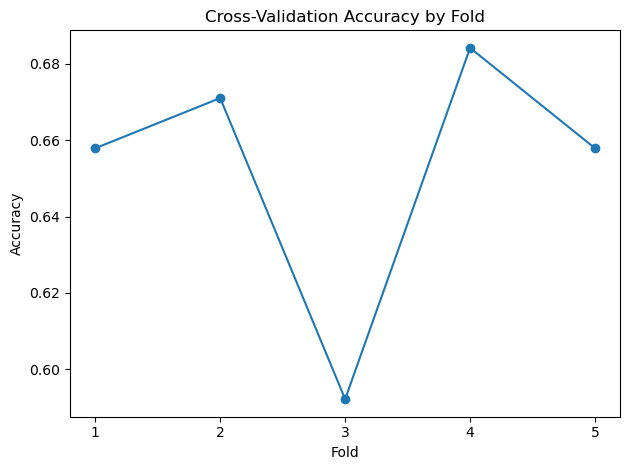

   Depth  Train_Accuracy  Test_Accuracy
0      1        0.601974       0.657895
1      2        0.700658       0.631579
2      3        0.726974       0.684211
3      4        0.773026       0.684211
4      5        0.828947       0.657895
5      6        0.858553       0.684211
6      7        0.917763       0.605263
7      8        0.957237       0.592105
8      9        0.980263       0.605263
9     10        0.990132       0.605263


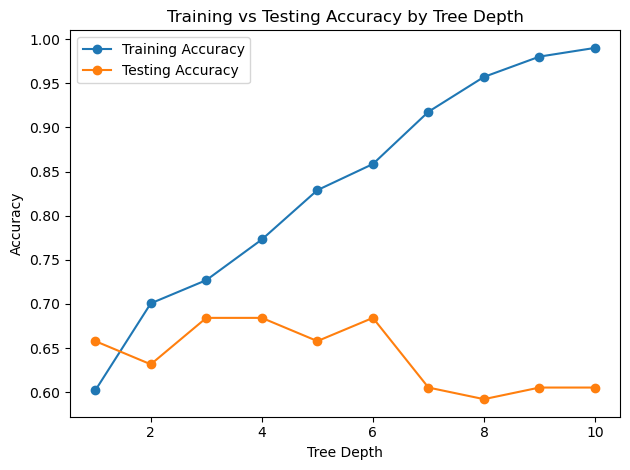

                                  Feature  Importance
5                 num__travel_distance_km    0.376949
6           num__clinic_wait_time_minutes    0.302195
24                 cat__reminder_sent_Yes    0.158650
1     num__days_before_appointment_booked    0.086176
12            cat__insurance_type_Private    0.049553
3              num__previous_appointments    0.026478
4                   num__appointment_hour    0.000000
23                  cat__reminder_sent_No    0.000000
22           cat__booking_channel_Website    0.000000
21           cat__booking_channel_Walk-in    0.000000
20             cat__booking_channel_Phone    0.000000
19        cat__booking_channel_Mobile App    0.000000
18       cat__appointment_type_Specialist    0.000000
17  cat__appointment_type_General Checkup    0.000000
16        cat__appointment_type_Follow-up    0.000000


<Figure size 640x480 with 0 Axes>

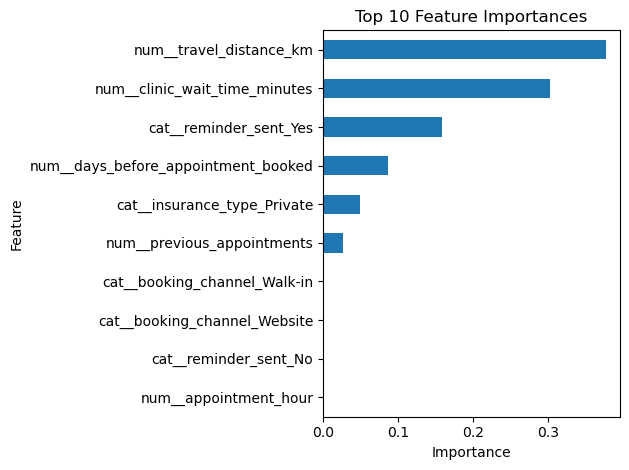

SHAP could not run. Error: No module named 'shap'
LIME is not installed. Install it using: pip install lime
Fairness summary for age_group
  age_group  Records  Actual_Positive_Rate  Predicted_Positive_Rate  Accuracy
0     18-25       13              0.461538                 0.153846  0.692308
1     26-35       16              0.375000                 0.250000  0.625000
2     36-50       12              0.416667                 0.333333  0.750000
3       51+       35              0.371429                 0.228571  0.685714


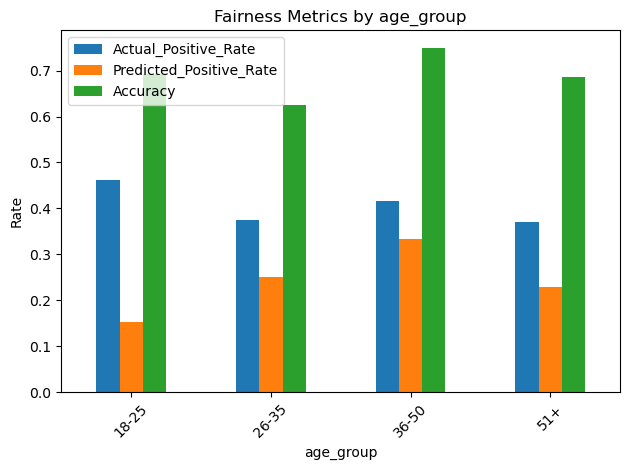

Fairness summary for gender
   gender  Records  Actual_Positive_Rate  Predicted_Positive_Rate  Accuracy
0  Female       37              0.405405                 0.216216  0.702703
1    Male       39              0.384615                 0.256410  0.666667


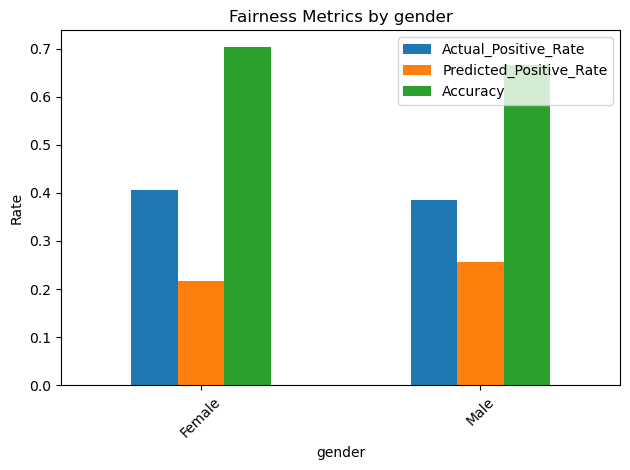

In [2]:
# Clinic Appointment No-Show Prediction Assignment
# Model Evaluation, Explainability, and Fairness Reflection

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# =============================
# Task 1: Load and understand data
# =============================
df = pd.read_csv("clinic_appointment_no_show_dataset.csv")
print("Dataset size:", df.shape)
print("Columns:", df.columns.tolist())
print("Data types:\n", df.dtypes)
print("Missing values:\n", df.isnull().sum())
print("Duplicate records:", df.duplicated().sum())
print("Target distribution:\n", df["no_show"].value_counts())

# =============================
# Task 2: Define features and target
# =============================
target_col = "no_show"
id_cols = ["appointment_id"]
fairness_cols = ["age_group", "gender"]

X = df.drop(columns=[target_col] + id_cols + fairness_cols)
y = df[target_col]
fairness_data = df[fairness_cols]

numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)

# =============================
# Task 3: Preprocessing
# =============================
numeric_transformer = SimpleImputer(strategy="median")
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_cols),
    ("cat", categorical_transformer, categorical_cols)
])

# =============================
# Task 4: Train/test split
# =============================
X_train, X_test, y_train, y_test, fair_train, fair_test = train_test_split(
    X, y, fairness_data, test_size=0.20, random_state=42, stratify=y
)
print("Training set size:", X_train.shape[0])
print("Testing set size:", X_test.shape[0])

# =============================
# Task 5: Train Decision Tree model
# =============================
model = DecisionTreeClassifier(max_depth=4, random_state=42)
pipe = Pipeline(steps=[("preprocess", preprocess), ("model", model)])
pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)

comparison = pd.DataFrame({"Actual": y_test.values, "Predicted": y_pred})
comparison["Correct"] = comparison["Actual"] == comparison["Predicted"]
print("Actual vs Predicted comparison:")
print(comparison.head(10))

# =============================
# Task 6: Model evaluation
# =============================
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)
print(classification_report(y_test, y_pred))

# =============================
# Task 7: Confusion matrix
# =============================
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)
TN, FP, FN, TP = cm.ravel()
print("TN:", TN, "FP:", FP, "FN:", FN, "TP:", TP)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks([0, 1], ["Attended", "No-show"])
plt.yticks([0, 1], ["Attended", "No-show"])
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.tight_layout()
plt.show()

# =============================
# Task 8: Error analysis
# =============================
def classify_error(actual, predicted):
    if actual == 0 and predicted == 0:
        return "True Negative"
    elif actual == 0 and predicted == 1:
        return "False Positive"
    elif actual == 1 and predicted == 0:
        return "False Negative"
    else:
        return "True Positive"

error_df = comparison.copy()
error_df["Error_Type"] = [classify_error(a, p) for a, p in zip(error_df["Actual"], error_df["Predicted"])]
print(error_df["Error_Type"].value_counts())
wrong_predictions = error_df[error_df["Correct"] == False]
print("Wrong predictions:")
print(wrong_predictions.head(10))

error_counts = error_df["Error_Type"].value_counts()
plt.figure()
error_counts.plot(kind="bar")
plt.title("Error Type Counts")
plt.xlabel("Error Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# =============================
# Task 9: Cross-validation
# =============================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(pipe, X, y, cv=cv, scoring="accuracy")
print("Cross-validation scores:", cv_scores)
print("Mean CV accuracy:", cv_scores.mean())
print("CV standard deviation:", cv_scores.std())

plt.figure()
plt.plot(range(1, 6), cv_scores, marker="o")
plt.title("Cross-Validation Accuracy by Fold")
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.xticks(range(1, 6))
plt.tight_layout()
plt.show()

# =============================
# Task 10: Overfitting/underfitting analysis
# =============================
depths = range(1, 11)
train_scores = []
test_scores = []

for depth in depths:
    temp_model = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", DecisionTreeClassifier(max_depth=depth, random_state=42))
    ])
    temp_model.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, temp_model.predict(X_train)))
    test_scores.append(accuracy_score(y_test, temp_model.predict(X_test)))

depth_df = pd.DataFrame({"Depth": list(depths), "Train_Accuracy": train_scores, "Test_Accuracy": test_scores})
print(depth_df)

plt.figure()
plt.plot(depths, train_scores, marker="o", label="Training Accuracy")
plt.plot(depths, test_scores, marker="o", label="Testing Accuracy")
plt.title("Training vs Testing Accuracy by Tree Depth")
plt.xlabel("Tree Depth")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

# =============================
# Task 11: Feature importance
# =============================
feature_names = pipe.named_steps["preprocess"].get_feature_names_out()
importances = pipe.named_steps["model"].feature_importances_
importance_df = pd.DataFrame({"Feature": feature_names, "Importance": importances}).sort_values(by="Importance", ascending=False)
print(importance_df.head(15))

plt.figure()
importance_df.head(10).sort_values("Importance").plot(x="Feature", y="Importance", kind="barh", legend=False)
plt.title("Top 10 Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

# =============================
# Task 12: SHAP explanation
# =============================
try:
    import shap
    X_train_processed = pipe.named_steps["preprocess"].transform(X_train)
    X_test_processed = pipe.named_steps["preprocess"].transform(X_test)
    tree_model = pipe.named_steps["model"]
    explainer = shap.TreeExplainer(tree_model)
    shap_values = explainer.shap_values(X_test_processed)
    # Summary plot for no-show class
    shap.summary_plot(shap_values[:, :, 1], X_test_processed, feature_names=feature_names)
    selected_index = 6
    print("Selected record prediction probability:", pipe.predict_proba(X_test.iloc[[selected_index]]))
except Exception as e:
    print("SHAP could not run. Error:", e)

# =============================
# Task 13: LIME explanation
# =============================
try:
    from lime.lime_tabular import LimeTabularExplainer
    X_train_processed = pipe.named_steps["preprocess"].transform(X_train)
    X_test_processed = pipe.named_steps["preprocess"].transform(X_test)
    X_train_array = X_train_processed.toarray() if hasattr(X_train_processed, "toarray") else X_train_processed
    X_test_array = X_test_processed.toarray() if hasattr(X_test_processed, "toarray") else X_test_processed
    explainer = LimeTabularExplainer(
        X_train_array,
        feature_names=feature_names,
        class_names=["Attended", "No-show"],
        mode="classification"
    )
    selected_index = 6
    explanation = explainer.explain_instance(
        X_test_array[selected_index],
        pipe.named_steps["model"].predict_proba,
        num_features=10
    )
    print("Prediction probability:", pipe.predict_proba(X_test.iloc[[selected_index]]))
    print(explanation.as_list())
    explanation.show_in_notebook(show_table=True)
except ImportError:
    print("LIME is not installed. Install it using: pip install lime")
except Exception as e:
    print("LIME could not run. Error:", e)

# =============================
# Task 14: Fairness and bias reflection
# =============================
fair_eval = fair_test.copy()
fair_eval["Actual"] = y_test.values
fair_eval["Predicted"] = y_pred
fair_eval["Correct"] = fair_eval["Actual"] == fair_eval["Predicted"]

for col in fairness_cols:
    fairness_summary = fair_eval.groupby(col).agg(
        Records=("Actual", "count"),
        Actual_Positive_Rate=("Actual", "mean"),
        Predicted_Positive_Rate=("Predicted", "mean"),
        Accuracy=("Correct", "mean")
    ).reset_index()
    print("Fairness summary for", col)
    print(fairness_summary)

    fairness_summary.plot(x=col, y=["Actual_Positive_Rate", "Predicted_Positive_Rate", "Accuracy"], kind="bar")
    plt.title(f"Fairness Metrics by {col}")
    plt.ylabel("Rate")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# =============================
# Task 15: Final interpretation is provided in the written report.
# =============================

# Assistant
This error occurs because the variable `df` (which likely contains your dataset) has not been defined or loaded before you try to use it. The code is trying to reference `df` somewhere to create the features or datasets, but `df` doesn't exist in the current namespace.

**Explanation:**
The code appears to be missing the initial steps where you would typically:
1. Import necessary libraries
2. Load your dataset into a DataFrame called `df`
3. Define `numerical_features`, `categorical_features`, `X_train`, `X_test`, `y_train`, etc.

Would you like me to provide the corrected code that includes the missing setup steps?